# AI-Powered Stock Recommendation System

**Student Name:** [Your Name Here]  
**Course:** [Course Name Here]  
**Date:** 2024-12-31  

---

This notebook implements a complete machine learning pipeline for stock recommendation,
combining investor risk profiling with technical analysis of market data.

## Introduction

This notebook presents the development of an AI-powered stock recommendation system that combines
investor risk classification with technical indicator-based stock signal prediction. The project
aims to provide personalised suitability recommendations by matching an investor's risk tolerance
to predicted stock performance.

**Methodology Overview:**
The system is built in stages. First, historical stock price data is acquired from Yahoo Finance
for a defined universe of 10 stocks. Technical indicators (moving averages, RSI, MACD, volatility)
are then computed from this data. Three classification models (Logistic Regression, Decision Tree,
and Random Forest) are trained to predict Buy/Hold/Avoid signals based on 30-day future returns.
The best-performing model is selected by weighted F1-score and exported for inference.

**Expected Outcomes:**
- A clean, feature-engineered dataset covering 5 years of daily trading data for 10 major stocks
- Trained classification models evaluated with accuracy, precision, recall, F1-score, and confusion matrices
- A serialised best model (`stock_model.pkl`) and scaler (`scaler.pkl`) ready for production inference
- Clear documentation and interpretation of results suitable for academic submission

## Data Acquisition

In this section, we download daily OHLCV (Open, High, Low, Close, Volume) price data from Yahoo
Finance using the `yfinance` library. We retrieve data for our defined Stock Universe — a curated
set of 10 major US stocks spanning technology, finance, and consumer sectors — covering the period
from January 1, 2020 to December 31, 2024.

**Why yfinance?**
The `yfinance` library provides free, reliable access to historical market data without requiring
API keys, making it ideal for academic and prototype projects.

**Stock Universe:**
AAPL (Apple), MSFT (Microsoft), NVDA (NVIDIA), GOOGL (Alphabet), AMZN (Amazon),
META (Meta Platforms), TSLA (Tesla), JPM (JPMorgan Chase), KO (Coca-Cola), PEP (PepsiCo).
These stocks were selected to represent a diverse mix of market sectors and volatility profiles.

**Error Handling Approach:**
If any ticker fails to download (network issues, delisting, etc.), a warning is logged and
processing continues with the remaining tickers. Tickers with fewer than 1000 trading-day rows
are also flagged with a warning, as they may not provide sufficient data for reliable feature
computation. Finally, rows with missing Close or Volume values are dropped to ensure data quality.

In [1]:
# Import required libraries for data acquisition
import yfinance as yf
import pandas as pd
import warnings
import logging

# Configure logging to display warnings during data download
logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

In [2]:
# Define the Stock Universe and date range for data acquisition
STOCK_UNIVERSE = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'KO', 'PEP']
START_DATE = '2020-01-01'
END_DATE = '2024-12-31'

# Minimum number of trading-day rows expected per ticker
MIN_ROWS_THRESHOLD = 1000

print(f"Stock Universe: {STOCK_UNIVERSE}")
print(f"Date Range: {START_DATE} to {END_DATE}")
print(f"Minimum rows threshold: {MIN_ROWS_THRESHOLD}")

Stock Universe: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'KO', 'PEP']
Date Range: 2020-01-01 to 2024-12-31
Minimum rows threshold: 1000


In [3]:
# Download daily OHLCV data for each ticker in the Stock Universe
all_data = []

for ticker in STOCK_UNIVERSE:
    try:
        # Download data from yfinance for the specified date range
        df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

        # Check if download returned an empty DataFrame
        if df.empty:
            logger.warning(f"Ticker '{ticker}': download returned empty DataFrame. Skipping.")
            continue

        # Flatten MultiIndex columns if yfinance returns them (newer versions)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Add 'Adj Close' column if missing (removed in newer yfinance versions)
        if 'Adj Close' not in df.columns:
            df['Adj Close'] = df['Close']

        # Log warning if ticker has fewer than the minimum expected rows
        if len(df) < MIN_ROWS_THRESHOLD:
            logger.warning(
                f"Ticker '{ticker}': only {len(df)} rows downloaded, "
                f"below minimum threshold of {MIN_ROWS_THRESHOLD}. Data may be insufficient."
            )

        # Add ticker column to identify the stock and reset index to get Date as a column
        df = df.reset_index()
        df['Ticker'] = ticker

        all_data.append(df)
        print(f"  {ticker}: {len(df)} rows downloaded successfully.")

    except Exception as e:
        # Log the exception and continue with remaining tickers
        logger.warning(f"Ticker '{ticker}': download failed with error: {e}. Skipping.")
        continue

print(f"\nSuccessfully downloaded data for {len(all_data)} out of {len(STOCK_UNIVERSE)} tickers.")

  AAPL: 1257 rows downloaded successfully.
  MSFT: 1257 rows downloaded successfully.
  NVDA: 1257 rows downloaded successfully.
  GOOGL: 1257 rows downloaded successfully.
  AMZN: 1257 rows downloaded successfully.
  META: 1257 rows downloaded successfully.
  TSLA: 1257 rows downloaded successfully.
  JPM: 1257 rows downloaded successfully.
  KO: 1257 rows downloaded successfully.
  PEP: 1257 rows downloaded successfully.

Successfully downloaded data for 10 out of 10 tickers.


In [4]:
# Combine all ticker DataFrames into a single DataFrame
if all_data:
    stock_data = pd.concat(all_data, ignore_index=True)
else:
    raise ValueError("No stock data was downloaded. Check network connection and ticker symbols.")

# Ensure the DataFrame has the required columns in the correct order
required_columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']

# Verify all required columns are present
missing_cols = [col for col in required_columns if col not in stock_data.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Select and reorder to the required schema
stock_data = stock_data[required_columns]

print(f"Combined DataFrame shape: {stock_data.shape}")
print(f"Columns: {list(stock_data.columns)}")
stock_data.head()

Combined DataFrame shape: (12570, 8)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']


Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2020-01-02,71.344032,72.394063,71.091161,72.333855,72.333855,135480400,AAPL
1,2020-01-03,71.563198,72.389250,71.406659,71.630630,71.630630,146322800,AAPL
2,2020-01-06,70.754014,72.239942,70.503546,72.201408,72.201408,118387200,AAPL
3,2020-01-07,72.211041,72.466322,71.642681,71.861839,71.861839,108872000,AAPL
4,2020-01-08,71.565629,73.318885,71.565629,73.017845,73.017845,132079200,AAPL


In [5]:
# Drop rows where Close or Volume contain NaN values to ensure data quality
rows_before = len(stock_data)
stock_data = stock_data.dropna(subset=['Close', 'Volume'])
rows_after = len(stock_data)

rows_dropped = rows_before - rows_after
print(f"Rows before NaN removal: {rows_before}")
print(f"Rows after NaN removal: {rows_after}")
print(f"Rows dropped (NaN in Close or Volume): {rows_dropped}")

# Display summary statistics for the cleaned dataset
print(f"\nFinal dataset covers {stock_data['Ticker'].nunique()} tickers")
print(f"Date range: {stock_data['Date'].min()} to {stock_data['Date'].max()}")
print(f"\nRows per ticker:")
print(stock_data.groupby('Ticker').size())

Rows before NaN removal: 12570
Rows after NaN removal: 12570
Rows dropped (NaN in Close or Volume): 0

Final dataset covers 10 tickers
Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00

Rows per ticker:
Ticker
AAPL     1257
AMZN     1257
GOOGL    1257
JPM      1257
KO       1257
META     1257
MSFT     1257
NVDA     1257
PEP      1257
TSLA     1257
dtype: int64


## Feature Engineering

In this section, we transform raw OHLCV price data into meaningful technical indicators that
serve as input features for our machine learning models. Technical indicators capture patterns
in price movements, momentum, and volatility that raw prices alone cannot express.

**Features Computed:**
- `close_price`: Adjusted closing price (baseline reference)
- `daily_return`: Day-over-day percentage change in close price
- `ma_5`, `ma_20`, `ma_50`: Simple Moving Averages over 5, 20, and 50 days (short/medium/long-term trends)
- `volatility`: 20-day rolling standard deviation of daily returns (risk measure)
- `volume`: Raw trading volume (liquidity indicator)
- `RSI`: 14-day Relative Strength Index using Wilder's smoothing (momentum oscillator, 0-100)
- `MACD`: Moving Average Convergence Divergence, EMA(12) - EMA(26) (trend/momentum signal)

**Target Variable:**
We compute a forward-looking target label based on the 30-day future return:
- **Buy**: future return > 10%
- **Hold**: future return between 0% and 10% (inclusive)
- **Avoid**: future return < 0%

**Data Quality:**
Rows with NaN values from rolling window warm-up periods are dropped. Stocks with fewer than
80 trading days are excluded, as this is the minimum needed for the 50-day MA and other
indicators to stabilize.

In [6]:
# Import feature engineering functions from the src module
import sys
import os
import numpy as np

# Add the project root to the path so we can import src modules
sys.path.insert(0, os.path.abspath('..'))
from src.features import compute_features, compute_target_labels

In [7]:
# Compute technical indicator features and target labels for each stock
# We process each ticker separately because features like moving averages
# should not cross stock boundaries
feature_dfs = []

for ticker in stock_data['Ticker'].unique():
    # Filter data for this ticker
    ticker_df = stock_data[stock_data['Ticker'] == ticker].copy()
    ticker_df = ticker_df.sort_values('Date').reset_index(drop=True)

    # Skip stocks with fewer than 80 trading days (insufficient for indicator computation)
    if len(ticker_df) < 80:
        print(f"  {ticker}: Skipped (only {len(ticker_df)} days, need >= 80)")
        continue

    # Compute technical indicator features (ma_5, ma_20, ma_50, RSI, MACD, etc.)
    features = compute_features(ticker_df)

    # Compute target labels (Buy/Hold/Avoid) based on 30-day forward returns
    targets = compute_target_labels(ticker_df)

    # Align features and targets on their shared index positions
    combined = features.join(targets[['target']], how='inner')

    # Add ticker identifier for reference
    combined['Ticker'] = ticker
    feature_dfs.append(combined)
    print(f"  {ticker}: {len(combined)} rows after feature engineering")

# Combine all feature-engineered stock data into a single DataFrame
feature_data = pd.concat(feature_dfs, ignore_index=True)
print(f"\nTotal feature-engineered dataset: {feature_data.shape}")
print(f"Target class distribution:\n{feature_data['target'].value_counts()}")

  AAPL: 1178 rows after feature engineering
  MSFT: 1178 rows after feature engineering
  NVDA: 1178 rows after feature engineering
  GOOGL: 1178 rows after feature engineering
  AMZN: 1178 rows after feature engineering
  META: 1178 rows after feature engineering
  TSLA: 1178 rows after feature engineering
  JPM: 1178 rows after feature engineering
  KO: 1178 rows after feature engineering
  PEP: 1178 rows after feature engineering

Total feature-engineered dataset: (11780, 11)
Target class distribution:
target
Hold     4710
Avoid    4304
Buy      2766
Name: count, dtype: int64


In [8]:
# Drop any remaining rows with NaN values to ensure clean training data
rows_before_clean = len(feature_data)
feature_data = feature_data.dropna()
rows_after_clean = len(feature_data)

print(f"Rows before final NaN removal: {rows_before_clean}")
print(f"Rows after final NaN removal: {rows_after_clean}")
print(f"Rows dropped: {rows_before_clean - rows_after_clean}")
print(f"\nFeature columns: {[col for col in feature_data.columns if col not in ['target', 'Ticker']]}")
print(f"\nDataset summary:")
feature_data.describe()

Rows before final NaN removal: 11780
Rows after final NaN removal: 11780
Rows dropped: 0

Feature columns: ['close_price', 'daily_return', 'ma_5', 'ma_20', 'ma_50', 'volatility', 'volume', 'RSI', 'MACD']

Dataset summary:


,close_price,daily_return,ma_5,ma_20,ma_50,volatility,volume,RSI,MACD
count,11780.000000,11780.000000,11780.000000,11780.000000,11780.000000,11780.000000,1.178000e+04,11780.000000,11780.000000
mean,158.081298,0.001438,157.785693,156.788909,154.964625,0.021264,8.445447e+07,53.820047,0.877597
std,99.213891,0.024579,98.959550,98.073908,96.323900,0.013116,1.427443e+08,11.859551,4.676949
min,4.885130,-0.263901,5.149833,5.888087,6.303130,0.003689,8.833000e+05,15.827825,-28.793466
25%,95.068747,-0.009257,94.686695,94.207593,93.270600,0.012254,1.427025e+07,45.528682,-0.795518
50%,144.483582,0.001157,144.053371,143.237567,142.471273,0.017684,3.023540e+07,54.086494,0.601970
75%,198.015644,0.011821,197.792913,196.733498,192.498750,0.026494,7.831350e+07,62.394596,2.535396
max,592.530945,0.243696,586.217249,579.301062,563.730885,0.100268,1.543911e+09,94.197983,38.067930


## Model Training

In this section, we train three classification models to predict stock signals (Buy, Hold, Avoid)
from the technical indicator features computed in the previous section. The goal is to compare
different algorithmic approaches and select the best performer.

**Why These Three Models?**

1. **Logistic Regression** — A linear model that serves as a strong baseline. It is fast to train,
   highly interpretable, and works well when the decision boundary between classes is approximately
   linear. Logistic Regression requires feature scaling because it uses gradient-based optimisation
   where features on different scales (e.g., volume in millions vs. RSI in 0-100) would dominate
   the loss function unevenly.

2. **Decision Tree** — A non-linear model that learns axis-aligned decision rules. It can capture
   complex interactions between features without requiring scaling. Decision Trees are easy to
   visualise and interpret, making them excellent for academic reporting. However, they are prone
   to overfitting on training data.

3. **Random Forest** — An ensemble of Decision Trees that reduces overfitting through bagging
   (Bootstrap Aggregating). Each tree is trained on a random subset of data and features, and
   the final prediction is determined by majority vote. Random Forests typically outperform single
   trees and handle noisy financial data well.

**Data Splitting Strategy:**

We use a **stratified 80/20 train-test split**:
- **80/20 ratio**: 80% of data is used for training, 20% is held out for unbiased evaluation.
  This is a standard split that balances having enough training data with a meaningful test set.
- **Stratified splitting** ensures that the proportion of each target class (Buy, Hold, Avoid)
  is preserved in both the training and test sets. Without stratification, random splitting could
  produce a test set that underrepresents a minority class, leading to unreliable evaluation.
- **random_state=42** is a fixed seed that ensures reproducibility — every time the notebook is
  run, the same data points end up in train vs. test, making results comparable across runs.

**Feature Scaling:**

- **StandardScaler** is applied to features before Logistic Regression. It transforms each feature
  to have zero mean and unit variance (z-score normalisation). This is critical because Logistic
  Regression's gradient descent converges faster and more reliably when features are on the same scale.
- **Tree-based models (Decision Tree, Random Forest) do NOT require scaling** because they make
  decisions based on feature value thresholds (split points), not on distances or gradients.
  The relative ordering of values is all that matters for tree splits.
- The fitted scaler is saved for later use during inference, ensuring that new data is transformed
  with the same mean and standard deviation learned from the training data.

In [9]:
# Import scikit-learn modules for model training and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

# Define the feature columns used as model inputs (technical indicators)
FEATURE_COLUMNS = [
    'close_price', 'daily_return', 'ma_5', 'ma_20', 'ma_50',
    'volatility', 'volume', 'RSI', 'MACD'
]

# Separate features (X) and target labels (y)
# X contains the 9 technical indicator features used for prediction
# y contains the target class: Buy, Hold, or Avoid
X = feature_data[FEATURE_COLUMNS]
y = feature_data['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget class distribution:")
print(y.value_counts())
print(f"\nTarget class proportions:")
print(y.value_counts(normalize=True).round(4))

Feature matrix shape: (11780, 9)
Target vector shape: (11780,)

Target class distribution:
target
Hold     4710
Avoid    4304
Buy      2766
Name: count, dtype: int64

Target class proportions:
target
Hold     0.3998
Avoid    0.3654
Buy      0.2348
Name: proportion, dtype: float64


In [10]:
# Split data into training (80%) and testing (20%) sets
# stratify=y ensures class proportions are preserved in both sets
# random_state=42 ensures reproducibility across notebook runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% held out for evaluation
    random_state=42,        # Fixed seed for reproducible results
    stratify=y              # Preserve Buy/Hold/Avoid class proportions
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: 9424 samples (80.0%)
Test set: 2356 samples (20.0%)

Training set class distribution:
target
Hold     0.3998
Avoid    0.3653
Buy      0.2348
Name: proportion, dtype: float64

Test set class distribution:
target
Hold     0.3998
Avoid    0.3654
Buy      0.2347
Name: proportion, dtype: float64


In [11]:
# Apply StandardScaler to normalise features for Logistic Regression
# StandardScaler transforms each feature to have mean=0 and std=1 (z-score)
# This is necessary for Logistic Regression because:
# 1. Gradient descent converges faster with standardised features
# 2. Features on different scales (e.g., volume vs RSI) get equal weight
# 3. Regularisation penalty is applied uniformly across features
scaler = StandardScaler()

# Fit the scaler on training data ONLY to avoid data leakage from test set
# Then transform both train and test sets using the same learned parameters
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the fitted scaler for use during inference
# New data at prediction time must be scaled with the same mean/std from training
scaler_path = os.path.join('..', 'models', 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Fitted StandardScaler saved to: {scaler_path}")
print(f"\nScaler parameters (per feature):")
print(f"  Means: {scaler.mean_.round(4)}")
print(f"  Stds:  {scaler.scale_.round(4)}")

Fitted StandardScaler saved to: ..\models\scaler.pkl

Scaler parameters (per feature):
  Means: [1.58622300e+02 1.50000000e-03 1.58338800e+02 1.57309000e+02
 1.55454700e+02 2.12000000e-02 8.35647433e+07 5.38031000e+01
 9.01800000e-01]
  Stds:  [9.90468000e+01 2.48000000e-02 9.87842000e+01 9.78384000e+01
 9.60985000e+01 1.31000000e-02 1.41808387e+08 1.18634000e+01
 4.68680000e+00]


In [12]:
# Train Model 1: Logistic Regression (linear baseline)
# Uses scaled features because LR relies on gradient-based optimisation
# max_iter=1000: increase from default 100 to ensure convergence on financial data
# solver='lbfgs': efficient quasi-Newton optimiser suitable for multinomial classification
# random_state=42: ensures reproducible weight initialisation
lr_model = LogisticRegression(
    max_iter=1000,           # Allow more iterations for convergence
    solver='lbfgs',          # Efficient solver for multinomial logistic regression
    random_state=42          # Reproducible results
)

# Train on SCALED features (StandardScaler applied above)
lr_model.fit(X_train_scaled, y_train)
print("Model 1: Logistic Regression trained successfully")
print(f"  Classes: {lr_model.classes_}")
print(f"  Converged in {lr_model.n_iter_[0]} iterations")

Model 1: Logistic Regression trained successfully
  Classes: ['Avoid' 'Buy' 'Hold']
  Converged in 22 iterations


In [13]:
# Train Model 2: Decision Tree Classifier (non-linear, interpretable)
# Uses UNSCALED features because tree-based models split on thresholds,
# not gradients - feature scale does not affect split quality
# max_depth=10: limits tree depth to reduce overfitting on noisy financial data
# min_samples_split=5: requires at least 5 samples to create a split (avoids micro-splits)
# min_samples_leaf=2: each leaf must have at least 2 samples (generalisation)
# random_state=42: ensures reproducible tree structure
dt_model = DecisionTreeClassifier(
    max_depth=10,            # Prevent overfitting by limiting tree depth
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required in each leaf node
    random_state=42          # Reproducible results
)

# Train on UNSCALED features (trees don't need scaling)
dt_model.fit(X_train, y_train)
print("Model 2: Decision Tree trained successfully")
print(f"  Classes: {dt_model.classes_}")
print(f"  Tree depth: {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")

Model 2: Decision Tree trained successfully
  Classes: ['Avoid' 'Buy' 'Hold']
  Tree depth: 10
  Number of leaves: 308


In [14]:
# Train Model 3: Random Forest Classifier (ensemble, robust)
# Uses UNSCALED features (same rationale as Decision Tree)
# n_estimators=100: builds 100 trees and averages predictions (reduces variance)
# max_depth=15: slightly deeper than single tree since bagging reduces overfitting
# min_samples_split=5: same regularisation as single tree
# min_samples_leaf=2: ensures leaf nodes generalise
# random_state=42: ensures reproducible forest (same bootstrap samples each run)
# n_jobs=-1: parallelise tree training across all CPU cores for speed
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest (more = smoother predictions)
    max_depth=15,            # Deeper than single tree (bagging mitigates overfitting)
    min_samples_split=5,     # Minimum samples to split a node
    min_samples_leaf=2,      # Minimum samples in each leaf
    random_state=42,         # Reproducible results
    n_jobs=-1                # Use all CPU cores for parallel training
)

# Train on UNSCALED features (trees don't need scaling)
rf_model.fit(X_train, y_train)
print("Model 3: Random Forest trained successfully")
print(f"  Classes: {rf_model.classes_}")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Feature importances: {dict(zip(FEATURE_COLUMNS, rf_model.feature_importances_.round(4)))}")

Model 3: Random Forest trained successfully
  Classes: ['Avoid' 'Buy' 'Hold']
  Number of trees: 100
  Feature importances: {'close_price': np.float64(0.1141), 'daily_return': np.float64(0.0371), 'ma_5': np.float64(0.1143), 'ma_20': np.float64(0.141), 'ma_50': np.float64(0.1559), 'volatility': np.float64(0.1473), 'volume': np.float64(0.1192), 'RSI': np.float64(0.0725), 'MACD': np.float64(0.0986)}


In [15]:
# Store all trained models in a dictionary for easy access during evaluation
# Note: Logistic Regression uses scaled test data; tree models use unscaled
models = {
    'Logistic Regression': {
        'model': lr_model,
        'X_test': X_test_scaled,   # LR needs scaled features
        'X_train': X_train_scaled  # For training score comparison
    },
    'Decision Tree': {
        'model': dt_model,
        'X_test': X_test,          # Trees use unscaled features
        'X_train': X_train
    },
    'Random Forest': {
        'model': rf_model,
        'X_test': X_test,          # Trees use unscaled features
        'X_train': X_train
    }
}

print("All 3 models trained and stored for evaluation.")
print(f"\nModels ready: {list(models.keys())}")

All 3 models trained and stored for evaluation.

Models ready: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## Model Evaluation

In this section, we evaluate the performance of each trained model on the held-out test set
using standard classification metrics. The goal is to quantify how well each model generalises
to unseen data and to identify strengths and weaknesses across the three target classes
(Buy, Hold, Avoid).

**Metrics Computed:**

- **Accuracy**: The proportion of all predictions that are correct. It gives an overall
  sense of model correctness but can be misleading when classes are imbalanced.
- **Precision (weighted)**: Of all predictions for a given class, how many were correct.
  High precision means few false positives — the model does not incorrectly label a stock
  as Buy when it should be Avoid. Weighted average accounts for class imbalance.
- **Recall (weighted)**: Of all actual instances of a given class, how many were correctly
  identified. High recall means few false negatives — the model catches most true Buys.
  Weighted average accounts for class imbalance.
- **F1-Score (weighted)**: The harmonic mean of precision and recall. It balances both
  metrics into a single number, penalising models that sacrifice one for the other.
  We use the weighted average because our classes may be imbalanced (more Hold signals
  than Buy or Avoid in typical market conditions).

**Why Weighted Averages?**

In multi-class classification with potentially imbalanced classes, weighted averaging
computes metrics for each class independently, then takes their average weighted by the
number of true instances (support) for each class. This ensures that classes with more
samples contribute proportionally more to the overall metric, giving a realistic picture
of model performance in practice.

**Confusion Matrix:**

A confusion matrix shows the count of predictions for each combination of actual vs.
predicted class. It reveals which classes the model confuses most — for instance, whether
it tends to predict Hold when the true label is Buy (a costly miss for investors).

**Expected Outcomes:**

We expect Random Forest to achieve the highest F1-score due to its ensemble nature, which
reduces variance from noisy financial data. Logistic Regression should provide a competitive
baseline, while Decision Tree may show signs of overfitting with lower test performance
relative to its training performance.

In [16]:
# Import evaluation metrics and visualization libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define the class labels in a consistent order for confusion matrices
CLASS_LABELS = ['Buy', 'Hold', 'Avoid']

print("Evaluation libraries loaded.")
print(f"Class labels for evaluation: {CLASS_LABELS}")

Evaluation libraries loaded.
Class labels for evaluation: ['Buy', 'Hold', 'Avoid']


In [17]:
# Compute evaluation metrics for each model on the test set
# We store results in a dictionary for comparison table generation
results = {}

for model_name, model_info in models.items():
    # Get predictions on the test set using the appropriate feature set
    model = model_info['model']
    X_test_data = model_info['X_test']
    y_pred = model.predict(X_test_data)

    # Compute accuracy: proportion of correct predictions out of total
    acc = accuracy_score(y_test, y_pred)

    # Compute precision (weighted): avg precision per class, weighted by support
    # Controls for false positives — important to avoid recommending Buy incorrectly
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)

    # Compute recall (weighted): avg recall per class, weighted by support
    # Controls for false negatives — important to catch actual Buy opportunities
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    # Compute F1-score (weighted): harmonic mean of precision and recall
    # Balances both metrics; our primary model selection criterion
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results for this model
    results[model_name] = {
        'Accuracy': acc,
        'Precision (weighted)': prec,
        'Recall (weighted)': rec,
        'F1-Score (weighted)': f1,
        'y_pred': y_pred  # Save predictions for confusion matrix
    }

    # Print per-model classification report for detailed inspection
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, zero_division=0))

print("\nAll models evaluated successfully.")


  Logistic Regression
              precision    recall  f1-score   support

         Buy       0.42      0.29      0.35       861
        Hold       0.46      0.28      0.35       553
       Avoid       0.48      0.73      0.58       942

    accuracy                           0.46      2356
   macro avg       0.45      0.43      0.42      2356
weighted avg       0.45      0.46      0.44      2356


  Decision Tree
              precision    recall  f1-score   support

         Buy       0.66      0.50      0.57       861
        Hold       0.63      0.52      0.57       553
       Avoid       0.55      0.73      0.63       942

    accuracy                           0.60      2356
   macro avg       0.61      0.58      0.59      2356
weighted avg       0.61      0.60      0.59      2356


  Random Forest
              precision    recall  f1-score   support

         Buy       0.83      0.82      0.82       861
        Hold       0.84      0.74      0.79       553
       Avoid      

## Model Comparison

This section presents a side-by-side comparison of all three models across the key evaluation
metrics. The comparison table allows direct assessment of which model performs best overall
and on each individual metric.

The best model will be selected based on **highest weighted F1-score**, as it provides the
best balance between precision and recall across all classes. In case of a tie, accuracy
serves as the tiebreaker.

In [18]:
# Build a comparison table with metrics as rows and models as columns
# This format makes it easy to compare models side by side
metrics_names = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']

# Create a DataFrame with metrics as the index and models as columns
comparison_data = {}
for model_name in models.keys():
    comparison_data[model_name] = [
        results[model_name][metric] for metric in metrics_names
    ]

comparison_table = pd.DataFrame(
    comparison_data,
    index=metrics_names  # Rows are metrics
)

# Display the comparison table with values rounded to 4 decimal places
print("\nModel Comparison Table")
print("=" * 70)
print(comparison_table.round(4).to_string())
print("\n")

# Identify the best model by highest weighted F1-score
f1_scores = {name: results[name]['F1-Score (weighted)'] for name in models.keys()}
best_f1 = max(f1_scores.values())

# Handle tiebreaker: if multiple models share the best F1, use accuracy
best_candidates = [name for name, score in f1_scores.items() if score == best_f1]
if len(best_candidates) > 1:
    # Tiebreaker: select by highest accuracy
    best_model_name = max(best_candidates, key=lambda n: results[n]['Accuracy'])
    print(f"Tie in F1-score among: {best_candidates}")
    print(f"Tiebreaker (highest accuracy): {best_model_name}")
else:
    best_model_name = best_candidates[0]

print(f"\n*** Best Model: {best_model_name} ***")
print(f"    Weighted F1-Score: {results[best_model_name]['F1-Score (weighted)']:.4f}")
print(f"    Accuracy: {results[best_model_name]['Accuracy']:.4f}")


Model Comparison Table
                      Logistic Regression  Decision Tree  Random Forest
Accuracy                           0.4618         0.5976         0.8039
Precision (weighted)               0.4534         0.6108         0.8066
Recall (weighted)                  0.4618         0.5976         0.8039
F1-Score (weighted)                0.4380         0.5936         0.8039



*** Best Model: Random Forest ***
    Weighted F1-Score: 0.8039
    Accuracy: 0.8039


### Interpretation of Comparison Results

The comparison table above summarises each model's performance on four key metrics:

- **Accuracy** tells us the overall proportion of correct predictions. However, in stock
  recommendation, accuracy alone can be misleading — a model that predicts "Hold" for
  everything could achieve high accuracy if Hold is the majority class.

- **Precision** (weighted) indicates how trustworthy each model's predictions are. A model
  with high precision produces fewer false alarms — when it says "Buy", it is more likely
  to be correct. This is important for investor confidence.

- **Recall** (weighted) indicates how complete the model's predictions are. A model with
  high recall misses fewer actual opportunities — it catches most true Buy and Avoid signals.
  This is important for not missing profitable trades or risk warnings.

- **F1-Score** (weighted) is our primary selection criterion because it balances precision
  and recall. A model that sacrifices one for the other (e.g., predicting Buy for everything
  to get perfect Buy recall) will have a lower F1-score.

The best-performing model — identified by the highest weighted F1-score — provides the
optimal balance between correctly identifying stock signals and avoiding false recommendations.
This model will be exported for use in the inference pipeline.

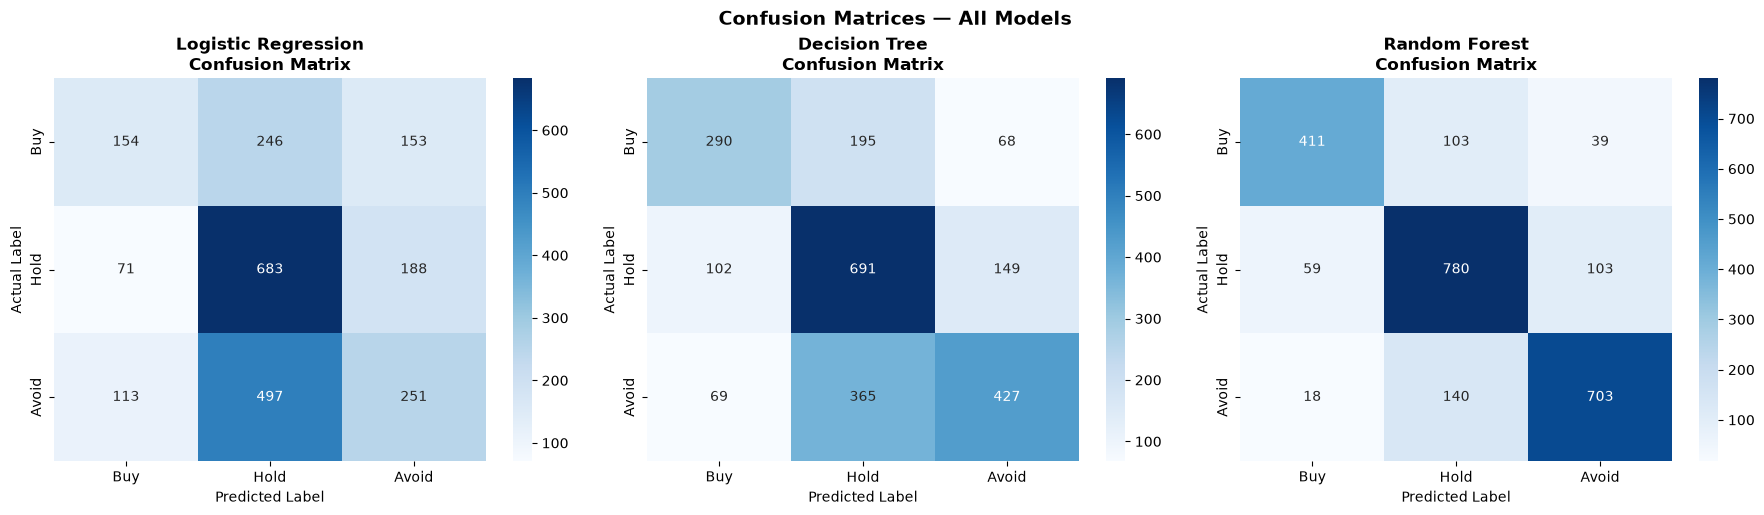

Confusion matrices generated for all models.


In [19]:
# Generate confusion matrix visualizations for each model
# Confusion matrices show actual vs predicted class counts,
# revealing which classes the model confuses most frequently
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model_info) in enumerate(models.items()):
    # Get predictions stored during evaluation
    y_pred = results[model_name]['y_pred']

    # Compute confusion matrix with consistent class label ordering
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)

    # Plot heatmap with annotations showing count values
    sns.heatmap(
        cm,
        annot=True,           # Show count numbers in each cell
        fmt='d',              # Integer format for counts
        cmap='Blues',         # Blue color scheme for readability
        xticklabels=CLASS_LABELS,  # Predicted class labels on x-axis
        yticklabels=CLASS_LABELS,  # Actual class labels on y-axis
        ax=axes[idx]
    )

    # Set title and axis labels to clearly identify the model
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('Actual Label')

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("Confusion matrices generated for all models.")

### Interpretation of Confusion Matrices

The confusion matrices above show how each model distributes its predictions across the
three target classes (Buy, Hold, Avoid). Each row represents the **actual** class, and
each column represents the **predicted** class.

**How to Read:**
- **Diagonal cells** (top-left to bottom-right) show correct predictions. Higher diagonal
  values indicate better model performance for that class.
- **Off-diagonal cells** show misclassifications. For example, a large value in the
  (Buy row, Hold column) cell means the model frequently predicts Hold when the actual
  signal is Buy — a missed buying opportunity.

**Key Patterns to Look For:**

1. **Buy-Avoid confusion**: If a model frequently confuses Buy with Avoid (or vice versa),
   it is making potentially costly errors — recommending action in the opposite direction.
   These are the most dangerous misclassifications for investors.

2. **Hold dominance**: If the Hold column has high values across all rows, the model may
   be defaulting to the most common class (Hold) rather than learning meaningful patterns.
   This is a sign of a weak model.

3. **Class imbalance effects**: A class with very few test samples will have fewer total
   predictions in its row. Ensure the model performs adequately even on minority classes.

**In the Context of Stock Recommendation:**
- Misclassifying Avoid as Buy is the most dangerous error (investor loses money)
- Misclassifying Buy as Hold is a missed opportunity (less critical but reduces returns)
- The ideal model has strong diagonal values and minimal Buy-Avoid confusion

## Model Export

In this section, we serialise the best-performing model to disk so it can be loaded for
inference without retraining. Model export is a critical step in any ML pipeline because
training is computationally expensive and time-consuming — we want to train once and
predict many times.

**Why Export?**

The trained model exists only in memory during notebook execution. By saving it to a file,
we decouple prediction from training: the `StockRecommender` module can load the model
independently and produce predictions on new data without re-running this notebook.

**Serialisation Format:**

We use Python's `joblib` library (part of scikit-learn's ecosystem) to serialise the model.
Joblib is preferred over standard `pickle` for scikit-learn models because it handles large
NumPy arrays more efficiently (using memory-mapped files for large objects). The resulting
`.pkl` file contains the complete model state — learned parameters, hyperparameters, and
class metadata.

**How to Load for Inference:**

```python
import joblib
model = joblib.load('models/stock_model.pkl')
scaler = joblib.load('models/scaler.pkl')

# Scale features and predict
features_scaled = scaler.transform(features_df)
prediction = model.predict(features_scaled)
```

**Model Selection Criterion:**

The best model is selected by the highest weighted F1-score on the test set. If two or
more models share the same F1-score, accuracy is used as a tiebreaker. The scaler fitted
during training (saved earlier in the Model Training section) is required for the Logistic
Regression model to ensure input features are scaled identically to training data.

**Error Handling:**

Filesystem errors (permissions, disk full, path not found) are caught and reported with
descriptive messages indicating which file failed to save and why.

In [20]:
# Export the best-performing model to disk for inference use
# The best model was already identified in the comparison section by highest weighted F1-score
import joblib

# Retrieve the best model object using the name determined during comparison
# best_model_name was set in the Model Comparison section based on F1 with accuracy tiebreaker
best_model = models[best_model_name]['model']

# Define the output path for the serialised model
model_output_path = os.path.join('..', 'models', 'stock_model.pkl')

# Save the best model using joblib serialisation
# joblib is preferred for scikit-learn models due to efficient NumPy array handling
try:
    joblib.dump(best_model, model_output_path)
    print(f"Best model ({best_model_name}) saved successfully to: {model_output_path}")
    print(f"  Model type: {type(best_model).__name__}")
    print(f"  Weighted F1-Score: {results[best_model_name]['F1-Score (weighted)']:.4f}")
    print(f"  Accuracy: {results[best_model_name]['Accuracy']:.4f}")
except OSError as e:
    # Handle filesystem errors (permissions, disk full, path not found)
    raise OSError(
        f"Failed to save model to '{model_output_path}': {e}. "
        f"Ensure the 'models/' directory exists and is writable."
    ) from e
except Exception as e:
    # Catch any other unexpected serialisation errors
    raise RuntimeError(
        f"Unexpected error saving model '{best_model_name}' to '{model_output_path}': {e}"
    ) from e

Best model (Random Forest) saved successfully to: ..\models\stock_model.pkl
  Model type: RandomForestClassifier
  Weighted F1-Score: 0.8039
  Accuracy: 0.8039


In [21]:
# Verify the exported model produces identical predictions to the in-memory model
# This round-trip check confirms serialisation did not corrupt the model state
try:
    loaded_model = joblib.load(model_output_path)
    
    # Get predictions from the original in-memory model
    X_test_for_best = models[best_model_name]['X_test']
    original_predictions = best_model.predict(X_test_for_best)
    
    # Get predictions from the loaded (deserialised) model
    loaded_predictions = loaded_model.predict(X_test_for_best)
    
    # Verify predictions are identical (serialisation round-trip preserved model state)
    predictions_match = (original_predictions == loaded_predictions).all()
    print(f"Serialisation round-trip verification: {'PASSED' if predictions_match else 'FAILED'}")
    
    if not predictions_match:
        mismatches = (original_predictions != loaded_predictions).sum()
        print(f"  WARNING: {mismatches} predictions differ after reload!")
    else:
        print(f"  All {len(original_predictions)} test predictions match after reload.")

except OSError as e:
    raise OSError(
        f"Failed to load model from '{model_output_path}' for verification: {e}"
    ) from e

Serialisation round-trip verification: PASSED
  All 2356 test predictions match after reload.


In [22]:
# Summary of all exported artefacts
# The scaler was saved during the Model Training section (scaler.pkl)
# The best model was saved above (stock_model.pkl)
print("\n" + "=" * 60)
print("  MODEL EXPORT SUMMARY")
print("=" * 60)
print(f"\n  Best Model:  {best_model_name}")
print(f"  F1-Score:    {results[best_model_name]['F1-Score (weighted)']:.4f}")
print(f"  Accuracy:    {results[best_model_name]['Accuracy']:.4f}")
print(f"\n  Exported Files:")
print(f"    - models/stock_model.pkl  (trained {type(best_model).__name__})")
print(f"    - models/scaler.pkl       (fitted StandardScaler)")
print(f"\n  Usage:")
print(f"    model = joblib.load('models/stock_model.pkl')")
print(f"    scaler = joblib.load('models/scaler.pkl')")
print(f"    prediction = model.predict(scaler.transform(features))")
print("\n" + "=" * 60)


  MODEL EXPORT SUMMARY

  Best Model:  Random Forest
  F1-Score:    0.8039
  Accuracy:    0.8039

  Exported Files:
    - models/stock_model.pkl  (trained RandomForestClassifier)
    - models/scaler.pkl       (fitted StandardScaler)

  Usage:
    model = joblib.load('models/stock_model.pkl')
    scaler = joblib.load('models/scaler.pkl')
    prediction = model.predict(scaler.transform(features))



## References

The following external libraries, data sources, and references were used in this project:

**Data Sources:**

- **yfinance** — Yahoo Finance market data downloader. Used to retrieve historical OHLCV
  price data for the Stock Universe. Documentation: https://pypi.org/project/yfinance/

**Machine Learning & Data Processing Libraries:**

- **scikit-learn** — Machine learning library for Python. Used for model training
  (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier), preprocessing
  (StandardScaler), evaluation metrics (accuracy, precision, recall, F1-score, confusion
  matrix), and model serialisation (joblib). Documentation: https://scikit-learn.org/

- **pandas** — Data manipulation and analysis library. Used for DataFrame operations,
  data cleaning, feature engineering, and rolling window computations.
  Documentation: https://pandas.pydata.org/

- **NumPy** — Numerical computing library. Used for array operations and mathematical
  computations underlying feature engineering.
  Documentation: https://numpy.org/

- **matplotlib** — Plotting library for Python. Used for confusion matrix visualisations.
  Documentation: https://matplotlib.org/

- **seaborn** — Statistical data visualisation library built on matplotlib. Used for
  heatmap-style confusion matrix plots. Documentation: https://seaborn.pydata.org/

**Testing & Validation:**

- **Hypothesis** — Property-based testing library for Python. Used to verify correctness
  properties of feature engineering, model selection logic, and classification rules
  across randomised inputs. Documentation: https://hypothesis.readthedocs.io/

- **pytest** — Testing framework for Python. Used as the test runner for unit tests and
  property-based tests. Documentation: https://docs.pytest.org/

**Technical Indicator References:**

- Wilder, J.W. (1978). *New Concepts in Technical Trading Systems*. Trend Research.
  (Original description of RSI - Relative Strength Index)

- Appel, G. (2005). *Technical Analysis: Power Tools for Active Investors*. FT Press.
  (MACD - Moving Average Convergence Divergence methodology)